# Makemore 3 : RNN and How the gradient behaves and Batch Normalization

In [5]:
%pip install torch matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 3.7 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.3 MB 3.8 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.3 MB 3.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 3.6 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.3 MB 3.6 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.3 MB 3.6 MB/s eta 0:00:02
   ----------------------------- ---------- 6.8/9.3 MB 3.5 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 3.6 MB/s eta 0:00:01
   ------------------------------------- 


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


#### Imports

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

#### Read the dataset

In [2]:
words = open("names.txt", "r").read().splitlines()
print(f'Total Names: {len(words)}')
print(f'First 8 names: {words[:8]}')

Total Names: 32033
First 8 names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


#### Build the vocabulary of the characters and the mappings to and from integers

In [3]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."]=0
itos={i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'Indexes to string dict: {itos}')
print(f'Len of Indexes to string dictionary (i.e Vocabulary size): {vocab_size}')

Indexes to string dict: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Len of Indexes to string dictionary (i.e Vocabulary size): 27


#### Build the dataset

In [4]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for word in words:
        context = [0]*block_size
        for char in word + ".":
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
    X= torch.tensor(X)
    Y= torch.tensor(Y)
    print(f'X-Shape:{X.shape}, Y-shape:{Y.shape}')
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #80%
Xdev, Ydev = build_dataset(words[n1:n2]) #10%
Xte, Yte = build_dataset(words[n2:]) #10%


X-Shape:torch.Size([182625, 3]), Y-shape:torch.Size([182625])
X-Shape:torch.Size([22655, 3]), Y-shape:torch.Size([22655])
X-Shape:torch.Size([22866, 3]), Y-shape:torch.Size([22866])


#### MLP Initiation Now

In [10]:
n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in the hioden layer of MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f'Total Number or parameters: {sum(i.nelement() for i in parameters)}')
for p in parameters:
    p.requires_grad=True

Total Number or parameters: 11897


X-mean:-0.01497971173375845, X-Std = 0.9993661642074585
Y-mean:-0.019234023988246918, Y-Std = 3.1568057537078857


(array([1.78156274e-05, 5.93854248e-06, 1.18770850e-05, 4.15697974e-05,
        5.34468823e-05, 5.34468823e-05, 9.50166797e-05, 1.95971902e-04,
        3.74128176e-04, 6.05731333e-04, 1.02736785e-03, 2.04285861e-03,
        3.23056711e-03, 5.54066014e-03, 9.63231591e-03, 1.53689479e-02,
        2.45796273e-02, 3.80601188e-02, 5.49137023e-02, 7.88994754e-02,
        1.01477814e-01, 1.22981276e-01, 1.33807239e-01, 1.35066210e-01,
        1.22423053e-01, 1.01560954e-01, 7.84600233e-02, 5.56085118e-02,
        3.86480345e-02, 2.44786721e-02, 1.53630094e-02, 9.55511485e-03,
        5.62379973e-03, 3.46810881e-03, 1.93002631e-03, 1.24115538e-03,
        5.76038621e-04, 3.56312549e-04, 1.66279190e-04, 6.53239673e-05,
        3.56312549e-05, 3.56312549e-05, 5.93854248e-06, 1.18770850e-05,
        0.00000000e+00, 5.93854248e-06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 5.93854248e-06]),
 array([-19.38813591, -18.54617847, -17.70422104, -16.8622636 ,
        -16.02030617, -15.1783

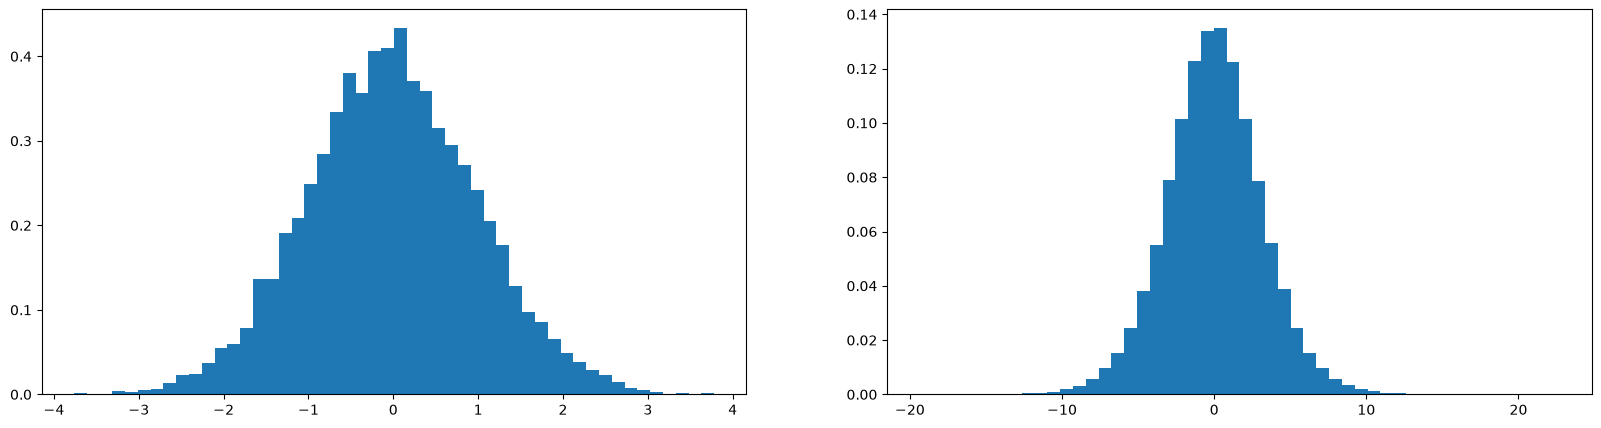

In [11]:
x = torch.randn(1000, 10)
w=torch.randn(10, 200)
y=x@w
print(f'X-mean:{x.mean()}, X-Std = {x.std()}')
print(f'Y-mean:{y.mean()}, Y-Std = {y.std()}')
plt.figure(figsize=(20, 5))
plt.subplot(121) 
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)


In [12]:
# As observed above, the standard deviation of the output increases as the number
# of inputs grows. To keep the activations approximately Gaussian with unit
# variance, we scale the weights by 1 / sqrt(fan_in), where fan_in is the number
# of input connections. This helps maintain stable variance across layers. 
# Look at the below discussion on why do we want our weights to be gaussian and less variant. 

#### ChatGPT discussion on why we love the weights to be gaussian:
**Variance** tells us how spread out values are.

For a neuron, suppose the output values are:

```python
[0.1, -0.2, 0.05, 0.3]
```

These are small and controlled, so variance is low.

But if outputs become:

```python
[25, -40, 18, 60]
```

Variance is huge. The activations have “blown up.”

In neural networks, variance matters because each layer passes its output to the next layer. So if variance keeps increasing layer by layer, values explode. If variance keeps decreasing, values shrink toward zero.

So we want:

```python
variance ≈ 1
standard deviation ≈ 1
```

because it keeps the signal stable as it moves through the network.

---

## Why do we want things to be Gaussian?

We do **not strictly need everything to be Gaussian**, but Gaussian-like behavior is useful because it is predictable and stable.

When we initialize weights randomly, we usually sample them from a distribution like:

```python
W = np.random.randn(...)
```

This gives values from a normal/Gaussian distribution.

A Gaussian distribution is nice because most values are near 0, and only a few are large:

```text
small values: common
large values: rare
```

That is useful because we want weights to start small and random, not huge.

---

## The real goal

The main goal is **not** “make everything Gaussian.”

The real goal is:

```text
Keep activations and gradients from exploding or vanishing.
```

Gaussian initialization is just a convenient way to start the network in a balanced state.

---

## Why divide by sqrt(fan_in)?

Suppose a neuron receives many inputs:

```python
y = x1*w1 + x2*w2 + x3*w3 + ... + xn*wn
```

When you add many random terms, their variance adds up.

So if there are `n` inputs, the output variance can become roughly `n` times larger.

To fix that, we scale the weights down:

```python
W = np.random.randn(fan_in, fan_out) / np.sqrt(fan_in)
```

This keeps the output variance approximately stable.

So instead of this happening:

```text
Layer 1 variance: 1
Layer 2 variance: 5
Layer 3 variance: 20
Layer 4 variance: 100
```

we want something like:

```text
Layer 1 variance: 1
Layer 2 variance: 1
Layer 3 variance: 1
Layer 4 variance: 1
```

That makes training much easier.

---

A good mental model:

```text
Variance = signal strength
Too high = explosion
Too low = vanishing
Around 1 = stable flow
Gaussian = convenient random starting shape
```


X-mean:-0.01026528887450695, X-Std = 1.0096561908721924
Y-mean:-0.000720391923096031, Y-Std = 1.0062607526779175


(array([4.66814000e-05, 2.33407000e-05, 4.66814000e-05, 2.33407000e-05,
        9.33628001e-05, 1.86725600e-04, 2.33407000e-04, 5.36836100e-04,
        1.14369430e-03, 2.35741070e-03, 3.50110500e-03, 5.53174590e-03,
        9.42964281e-03, 1.65252156e-02, 2.33173593e-02, 3.61314036e-02,
        5.11628144e-02, 7.45035145e-02, 1.05826734e-01, 1.41888115e-01,
        1.84975048e-01, 2.46244385e-01, 3.01771911e-01, 3.55642246e-01,
        4.11940015e-01, 4.30402508e-01, 4.18848862e-01, 3.93360817e-01,
        3.42127981e-01, 2.86927225e-01, 2.24607556e-01, 1.74635118e-01,
        1.30217765e-01, 9.51366933e-02, 6.65910171e-02, 4.64246523e-02,
        3.26536393e-02, 1.90693519e-02, 1.37243316e-02, 8.30928921e-03,
        4.62145860e-03, 3.17433520e-03, 1.89059670e-03, 1.02699080e-03,
        5.83517500e-04, 4.66814000e-04, 1.16703500e-04, 7.00221000e-05,
        0.00000000e+00, 7.00221000e-05]),
 array([-5.53791857, -5.32370049, -5.1094824 , -4.89526432, -4.68104624,
        -4.46682816, 

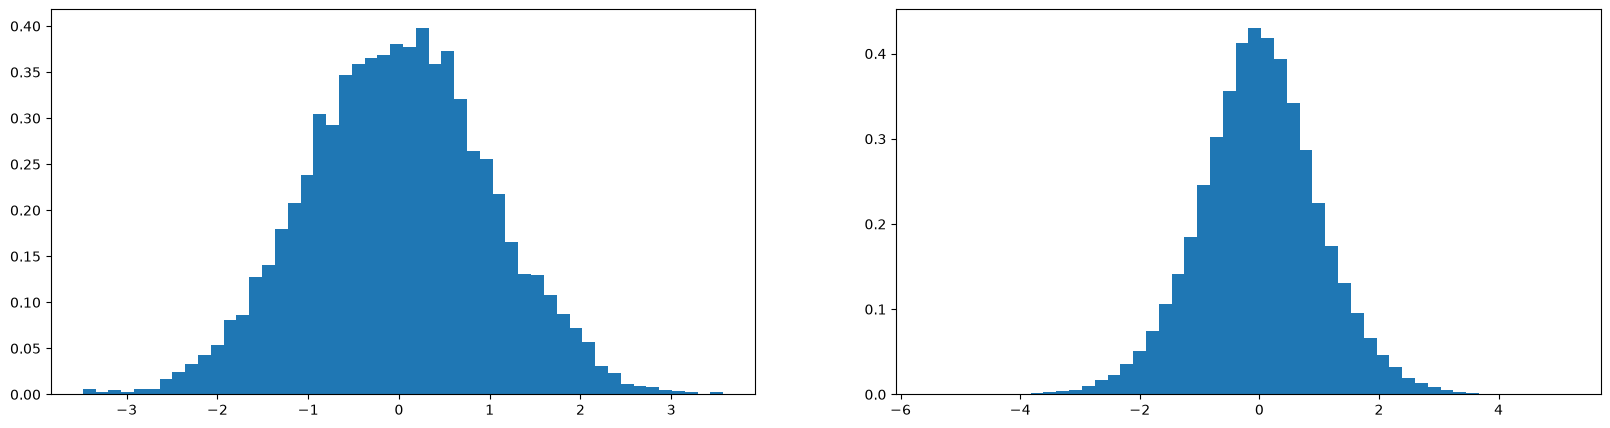

In [13]:
# Implement weight initialization optimization to keep weights gaussian and SD and Var as ~1
x = torch.randn(1000, 10)
w=torch.randn(10, 200)/(10)**0.5
y=x@w
print(f'X-mean:{x.mean()}, X-Std = {x.std()}')
print(f'Y-mean:{y.mean()}, Y-Std = {y.std()}')
plt.figure(figsize=(20, 5))
plt.subplot(121) 
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)


<p>Now that we have the initializations handled, modern techniques allow us to not give that much fuck to these elements.</p?>
Now that we have forcefully squished the weights this leads the whole weight squeeze so much that the training is also not able to affect these much and so we have to normalize for these gains. 

Before the paper of Batch normalization was written everything had to be done very precisely and everything was fragile. 
One would have to do things more precisely in case of deep neural netwiorks. 

Modern innovations have allowed us to not give so much fuck to these very precise, fragile initialization and thus allowing us to have much better control and with ease. 

Things like the following helped us to be free from the tension of precise fragile initilization (especially in deep neural networks)
1. Residual corrections
2. Use of number of normalization layers (Batch, layer, Group)
3. Better optimizers (RMS Prob, Adam) 



Generally dividing by sqrt(fan_in) is okay but more precisely. 
Let's say you have the standard deviation of 1000 elements, it's close to 1. Now if you multiply the whole array of elements by some factor then the standard deviation gets equal to that factor. So to set the deviation to make the elements gaussian is gan/sqrt(fan_in). 
So doing that.

In [14]:
n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in the hioden layer of MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
fan_in = n_embd * block_size
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3) / (fan_in)**0.5 # gain/sqrt(fan_in) = khiming non lineariaty
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f'Total Number or parameters: {sum(i.nelement() for i in parameters)}')
for p in parameters:
    p.requires_grad=True

Total Number or parameters: 11897


#### Now optimize

In [15]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # Hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000:3.3179
  10000/ 200000:2.1910
  20000/ 200000:2.3270
  30000/ 200000:2.5396
  40000/ 200000:1.9468
  50000/ 200000:2.3331
  60000/ 200000:2.3852
  70000/ 200000:2.1173
  80000/ 200000:2.3159
  90000/ 200000:2.2010
 100000/ 200000:1.8591
 110000/ 200000:2.0881
 120000/ 200000:1.9389
 130000/ 200000:2.3913
 140000/ 200000:2.0949
 150000/ 200000:2.1458
 160000/ 200000:1.7824
 170000/ 200000:1.7249
 180000/ 200000:1.9752
 190000/ 200000:1.8614


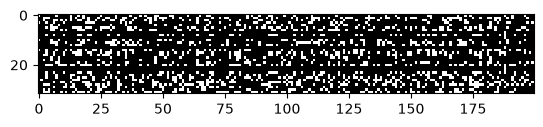

In [16]:
plt.Figure(figsize=(20, 10))
plt.imshow(h.abs()>0.99, cmap="gray", interpolation="nearest")

#### Evaluate Loss for the training

In [17]:
# 4 dimensional example
# logits = torch.tensor([-0.0249,  0.3523, -0.1267,  0.0541,  0.1662, -0.1171, -0.0140,  0.0124,
#          0.0921,  0.1135,  0.1362, -0.0925,  0.0444, -0.2459, -0.0971,  0.0125,
#         -0.0957, -0.1376, -0.2329, -0.0137,  0.2452,  0.1616,  0.1665, -0.1094,
#         -0.2154,  0.0725,  0.1141])
# probs = F.softmax(logits, dim=0)
# loss = -probs[2].log()
# probs, loss, probs[0]

In [18]:
h

tensor([[ 0.9997,  0.6480, -0.9192,  ..., -0.9500,  0.9884,  0.9667],
        [ 0.9833, -0.4884, -0.9949,  ..., -0.9982,  0.4785,  0.1835],
        [-0.9390,  0.9812, -0.9934,  ..., -0.5631, -0.9470,  0.7932],
        ...,
        [ 0.8058, -0.9363, -0.9838,  ..., -0.6065, -0.8019, -0.9144],
        [ 0.6071,  0.7413,  0.9997,  ..., -0.9813, -0.8110,  0.9684],
        [ 0.0827, -0.6796, -1.0000,  ..., -0.5346, -0.8945,  0.1456]],
       grad_fn=<TanhBackward0>)

(array([1059.,  229.,  163.,  142.,   95.,   83.,   67.,   63.,   57.,
          65.,   76.,   51.,   69.,   65.,   85.,   91.,   75.,   53.,
          62.,   76.,   70.,  100.,  117.,   91.,  110.,  125.,  104.,
          72.,  108.,   70.,   62.,   62.,   65.,   64.,   54.,   58.,
          65.,   62.,   53.,   53.,   53.,   66.,   67.,   81.,   93.,
         101.,  116.,  178.,  232., 1122.]),
 array([-9.99999940e-01, -9.59999942e-01, -9.19999943e-01, -8.79999944e-01,
        -8.39999945e-01, -7.99999946e-01, -7.59999948e-01, -7.19999949e-01,
        -6.79999950e-01, -6.39999951e-01, -5.99999952e-01, -5.59999954e-01,
        -5.19999955e-01, -4.79999956e-01, -4.39999957e-01, -3.99999958e-01,
        -3.59999959e-01, -3.19999961e-01, -2.79999962e-01, -2.39999963e-01,
        -1.99999964e-01, -1.59999965e-01, -1.19999967e-01, -7.99999678e-02,
        -3.99999690e-02,  2.98023224e-08,  4.00000286e-02,  8.00000274e-02,
         1.20000026e-01,  1.60000025e-01,  2.00000024e-01,  2.400000

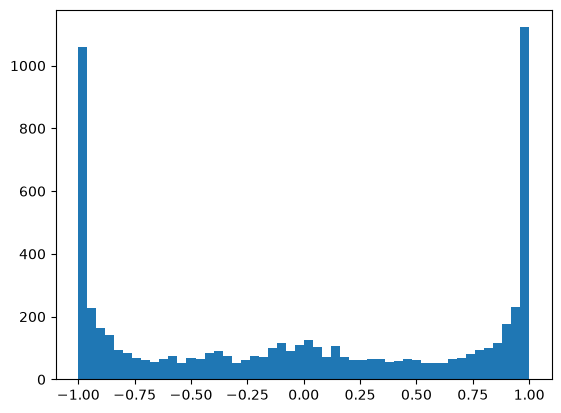

In [19]:
plt.hist(h.view(-1).tolist(), 50)

(array([  4.,   3.,   0.,   6.,   4.,   8.,   9.,  14.,  32.,  30.,  39.,
         69.,  68.,  73., 124., 156., 164., 192., 232., 291., 319., 368.,
        630., 891., 491., 340., 310., 299., 224., 221., 173., 124., 112.,
         92.,  67.,  43.,  49.,  31.,  34.,  21.,  17.,   8.,   3.,   4.,
          5.,   1.,   1.,   1.,   2.,   1.]),
 array([-8.91664505, -8.53550545, -8.15436584, -7.77322624, -7.39208664,
        -7.01094704, -6.62980743, -6.24866783, -5.86752823, -5.48638863,
        -5.10524902, -4.72410942, -4.34296982, -3.96183022, -3.58069061,
        -3.19955101, -2.81841141, -2.4372718 , -2.0561322 , -1.6749926 ,
        -1.293853  , -0.91271339, -0.53157379, -0.15043419,  0.23070541,
         0.61184502,  0.99298462,  1.37412422,  1.75526382,  2.13640343,
         2.51754303,  2.89868263,  3.27982224,  3.66096184,  4.04210144,
         4.42324104,  4.80438065,  5.18552025,  5.56665985,  5.94779945,
         6.32893906,  6.71007866,  7.09121826,  7.47235786,  7.85349747,
 

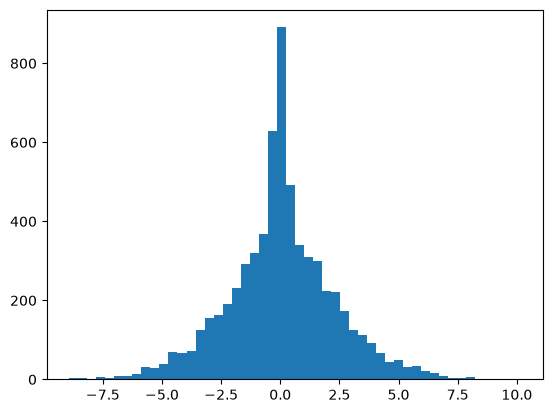

In [20]:
plt.hist(hpreact.view(-1).tolist(), 50)

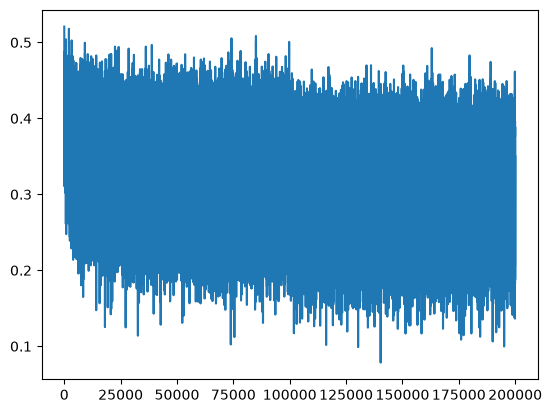

In [21]:
plt.plot(lossi)

#### Now Evaluate

In [22]:
@torch.no_grad() # this decorator disables gradient tracking and saves space
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val":(Xdev, Ydev), 
        "test":(Xte, Yte)
    }[split]
    emb = C[x] # N, block_size, n_embd
    embcat  = emb.view(emb.shape[0], -1) # Concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")


train 2.0376641750335693
val 2.106989622116089


#### Batch Normalization. (Introduced in 2015 by Google)

<p>
In short batch normalization says that if you want your all hidden states to be roughly gaussian, then why not take them and normalize them to be gaussian?
This concept just worked very well. So that's how we do the batch normalization. 

This sounds crazy but standardizing the hidden layers to be gaussian is a perfectly differentiable operation. 
</p>

In [23]:
n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in the hioden layer of MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
fan_in = n_embd * block_size
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3) / (fan_in)**0.5 # gain/sqrt(fan_in) = khiming non lineariaty
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# Batch normalization Scale and shift step
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(f'Total Number or parameters: {sum(i.nelement() for i in parameters)}')
for p in parameters:
    p.requires_grad=True

Total Number or parameters: 12297


In [24]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) - bnbias # Batch normalization
    h = torch.tanh(hpreact) # Hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000:3.3147
  10000/ 200000:2.1984
  20000/ 200000:2.3375
  30000/ 200000:2.4359
  40000/ 200000:2.0119
  50000/ 200000:2.2595
  60000/ 200000:2.4775
  70000/ 200000:2.1020
  80000/ 200000:2.2788
  90000/ 200000:2.1862
 100000/ 200000:1.9474
 110000/ 200000:2.3010
 120000/ 200000:1.9837
 130000/ 200000:2.4523
 140000/ 200000:2.3839
 150000/ 200000:2.1987
 160000/ 200000:1.9733
 170000/ 200000:1.8668
 180000/ 200000:1.9973
 190000/ 200000:1.8347


<p>One more crazy benefit of Batch normalization is that by introducing all the noise like bnweight and bnbias, the "h" also jitters a bit and is actually a kind of augmentator that looks jittery, but that's good, it allows and helps the neural net overfit. Basically it also acts like regularizer. This makes batch normalization a necessary kinda steps, some other kinds of way arounds were tried to find instead of batch normalization like layer normalization, instance normalization, group normalization, etc. This batch normalization bitch is actually coupled mathematically in the forward pass. But batch normalization intrduces a lots of bugs and all... It was the first kind of normalization introduced. But it was very hard to replace it cuz it is a kind of regularizer.</p>

In [25]:
@torch.no_grad() # this decorator disables gradient tracking and saves space
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val":(Xdev, Ydev), 
        "test":(Xte, Yte)
    }[split]
    emb = C[x] # N, block_size, n_embd
    embcat  = emb.view(emb.shape[0], -1) # Concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) - bnbias # Batch normalization

    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")


train 2.0668270587921143
val 2.104844808578491


#### Training Logs
1. v1 (Raw Single layer MLP)
- train 2.0355966091156006
- val 2.1026782989501953
---
2. v2 (Proper surgical initialization of weights)
- train 2.0376641750335693
- val 2.106989622116089
---
3. V3 (V2 + Batch Normalization)
- train 2.0668270587921143
- val 2.104844808578491
<p>(it's a very simple neural network and so there's no significant improvement, but in a deep neural network batch normalization helps)</p>

#### Now Sample the model

In [26]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0]* block_size

    while True:
        # Forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1)@W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # Sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # Shift the sample window and track the samples
        context = context[1:]+[ix]
        out.append(ix)

        # if we sample special token ".", then break
        if ix ==0:
            break

    print("".join(itos[i] for i in out))

briangmyazziyes.
bdulyah.
briyas.
brdrner.
sherkodrlithlyllsenleigh.
santhannchyziohmkrrnn.
shdumrishimnest.
jadestly.
prgbdulfuubdgghder.
jaquezmashburjahsis.
dashby.
sadya.
sus.
zakquslutel.
subristia.
sumprrdnn.
quloeonandphillsamreyxa.
hunton.
bdasirfalvinnwrllwildtalfr.
tandysestss.


#### One weird outcome of batch normalization

<p>
Once we've trained a neural net, we'd like to deploy it. Basically we will want the neural net to accept a single input and generate predictions. 
But because of batch normalization, how do we get the forward passs as the neural net now expexts and needs the mean and std deviation of a BATCH? 
Basically because of batch normalization, our neural net NOW expects a betch of input. 

Here's how:
Add a step after training that calculates the mean and std deviation of the training set single time
</p>

In [27]:
# Caliberate for deploying
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1  + b1

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)

In [28]:
@torch.no_grad() # this decorator disables gradient tracking and saves space
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val":(Xdev, Ydev), 
        "test":(Xte, Yte)
    }[split]
    emb = C[x] # N, block_size, n_embd
    embcat  = emb.view(emb.shape[0], -1) # Concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    hpreact = bngain * (hpreact - bnmeani) / bnstdi - bnbias # Batch normalization

    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")


train 2.0668270587921143
val 2.1049270629882812


<p>
But no one likes to generate the bnmean and bnstd after the training. Cuz they are lazy. So the 2015 paper also introduced one more way to do it, i.e by generating them in the training but in a running manner. Here's how:
</p>

In [29]:
n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in the hioden layer of MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
fan_in = n_embd * block_size
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3) / (fan_in)**0.5 # gain/sqrt(fan_in) = khiming non lineariaty
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# Batch normalization Scale and shift step
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros(1, n_hidden)
bnstd_running = torch.ones(1, n_hidden)

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(f'Total Number or parameters: {sum(i.nelement() for i in parameters)}')
for p in parameters:
    p.requires_grad=True

Total Number or parameters: 12297


In [30]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi - bnbias # Batch normalization

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact) # Hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000:3.3147
  10000/ 200000:2.1984
  20000/ 200000:2.3375
  30000/ 200000:2.4359
  40000/ 200000:2.0119
  50000/ 200000:2.2595
  60000/ 200000:2.4775
  70000/ 200000:2.1020
  80000/ 200000:2.2788
  90000/ 200000:2.1862
 100000/ 200000:1.9474
 110000/ 200000:2.3010
 120000/ 200000:1.9837
 130000/ 200000:2.4523
 140000/ 200000:2.3839
 150000/ 200000:2.1987
 160000/ 200000:1.9733
 170000/ 200000:1.8668
 180000/ 200000:1.9973
 190000/ 200000:1.8347


In [31]:
print(f'bnmean_running:{bnmean_running}, bnstd_running:{bnstd_running}')

bnmean_running:tensor([[-2.3539,  0.6872, -0.9001,  1.0159,  1.0894,  1.0862,  1.7389, -2.1357,
          0.5608,  1.4247, -1.6445, -2.7426, -0.4861, -0.1510, -0.0687, -1.1550,
          0.6891, -2.6399, -0.1283,  1.6240, -0.7732, -0.2865,  0.0467,  0.6119,
          1.1172,  0.2433,  2.0542,  0.5778,  0.8515,  1.7729, -0.3741, -0.8385,
         -0.0831, -0.5198, -0.3816, -1.0698, -0.0781,  0.3370, -0.5768,  0.9935,
         -0.4507, -1.3313, -0.2895, -0.2299,  0.6877,  0.6936,  2.0835, -0.7759,
          2.3804,  1.8613,  0.8118,  0.2735,  1.8801,  0.4705,  0.6656, -1.8962,
         -0.0420,  0.4356,  1.3924, -0.8906, -0.4676,  1.1688,  0.5539,  0.6001,
          1.5853,  1.2103, -1.0171,  2.1421, -0.6330,  0.1071, -0.2926, -0.4831,
          0.9506, -1.0144, -2.9925,  0.6268,  1.4404, -0.1574,  0.0955,  0.5159,
          0.2487,  1.2401,  2.0104,  0.6695,  0.0768, -0.0851, -1.6767,  0.2963,
          2.2374, -0.0100, -0.6669,  1.4356, -0.8431, -1.2317, -1.0220,  0.2201,
          0.1

In [32]:
bnmean

NameError: name 'bnmean' is not defined

In [33]:
bnmean_running

tensor([[-2.3539,  0.6872, -0.9001,  1.0159,  1.0894,  1.0862,  1.7389, -2.1357,
          0.5608,  1.4247, -1.6445, -2.7426, -0.4861, -0.1510, -0.0687, -1.1550,
          0.6891, -2.6399, -0.1283,  1.6240, -0.7732, -0.2865,  0.0467,  0.6119,
          1.1172,  0.2433,  2.0542,  0.5778,  0.8515,  1.7729, -0.3741, -0.8385,
         -0.0831, -0.5198, -0.3816, -1.0698, -0.0781,  0.3370, -0.5768,  0.9935,
         -0.4507, -1.3313, -0.2895, -0.2299,  0.6877,  0.6936,  2.0835, -0.7759,
          2.3804,  1.8613,  0.8118,  0.2735,  1.8801,  0.4705,  0.6656, -1.8962,
         -0.0420,  0.4356,  1.3924, -0.8906, -0.4676,  1.1688,  0.5539,  0.6001,
          1.5853,  1.2103, -1.0171,  2.1421, -0.6330,  0.1071, -0.2926, -0.4831,
          0.9506, -1.0144, -2.9925,  0.6268,  1.4404, -0.1574,  0.0955,  0.5159,
          0.2487,  1.2401,  2.0104,  0.6695,  0.0768, -0.0851, -1.6767,  0.2963,
          2.2374, -0.0100, -0.6669,  1.4356, -0.8431, -1.2317, -1.0220,  0.2201,
          0.1928, -0.3261,  

In [34]:
bnstd

NameError: name 'bnstd' is not defined

In [ ]:
bnstd_running

See above bnmean running and bnmean from the old method are very similar, that's how to be lazy and not calculate the bnmean after training and calculate it instad while triaing. Same is for bnstd, bnstd running. 

Now that we are using bnmean it actually totally removes the effect of b1 bias as the biasses added previously, the mean and subtraction removes it totally so why be wasteful and remove b1 completely as we are already suing bnbias. Here's how:

In [35]:
n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in the hioden layer of MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
fan_in = n_embd * block_size
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3) / (fan_in)**0.5 # gain/sqrt(fan_in) = khiming non lineariaty
# b1 = torch.randn(n_hidden, generator=g) * 0.01 # Now because of the mean and subrtration of bn,ean we are actually not using it at all as the bnbias does the job nicely. 
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# Batch normalization Scale and shift step
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros(1, n_hidden)
bnstd_running = torch.ones(1, n_hidden)

parameters = [C, W1, W2, b2, bngain, bnbias]
print(f'Total Number or parameters: {sum(i.nelement() for i in parameters)}')
for p in parameters:
    p.requires_grad=True

Total Number or parameters: 12097


In [36]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation : Becauuse of batch normalization bnmean removes the dependency of b1 and bnbias creates a bias accordingly. So no need to add b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi - bnbias # Batch normalization

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact) # Hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000:3.3239
  10000/ 200000:2.0322
  20000/ 200000:2.5675
  30000/ 200000:2.0125
  40000/ 200000:2.2446
  50000/ 200000:1.8897
  60000/ 200000:2.0785
  70000/ 200000:2.3681
  80000/ 200000:2.2918
  90000/ 200000:2.0238
 100000/ 200000:2.3673
 110000/ 200000:2.3132
 120000/ 200000:1.6414
 130000/ 200000:1.9311
 140000/ 200000:2.2231
 150000/ 200000:2.0027
 160000/ 200000:2.0997
 170000/ 200000:2.4949
 180000/ 200000:2.0199
 190000/ 200000:2.1707


## Now let's PyTorchify the code and see the activation functions more closely in forward and backward pass. 

In [24]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True, generator=None):
        self.generator = generator if generator is not None else torch.Generator().manual_seed(2147483647)
        self.weight = torch.randn(fan_in, fan_out, generator=self.generator) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # Parameters trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers - Trained with a running momentum
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # Calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta

        # Update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [25]:
n_embd = 10 
n_hidden = 100
block_size = 3
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd*block_size, n_hidden), Tanh(),
    Linear(                   n_hidden, n_hidden), Tanh(),
    Linear(                   n_hidden, n_hidden), Tanh(),
    Linear(                   n_hidden, n_hidden), Tanh(),
    Linear(                   n_hidden, n_hidden), Tanh(),
    Linear(                   n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
num_parameters = sum(p.nelement() for p in parameters)
print(f'Num of Parameters:{num_parameters}')
for p in parameters:
    p.requires_grad=True

Num of Parameters:46497


In [26]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    x = emb.view(emb.shape[0], -1) # Concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

      0/ 200000:3.2950


Layer: 1 (Tanh) mean: 0.0210, std: 0.7450, saturated: 18.84%
Layer: 3 (Tanh) mean: 0.0019, std: 0.6732, saturated: 8.47%
Layer: 5 (Tanh) mean: 0.0076, std: 0.6516, saturated: 6.53%
Layer: 7 (Tanh) mean: 0.0429, std: 0.6423, saturated: 5.22%
Layer: 9 (Tanh) mean: -0.0203, std: 0.6394, saturated: 4.22%


Text(0.5, 1.0, 'Activation Distribution')

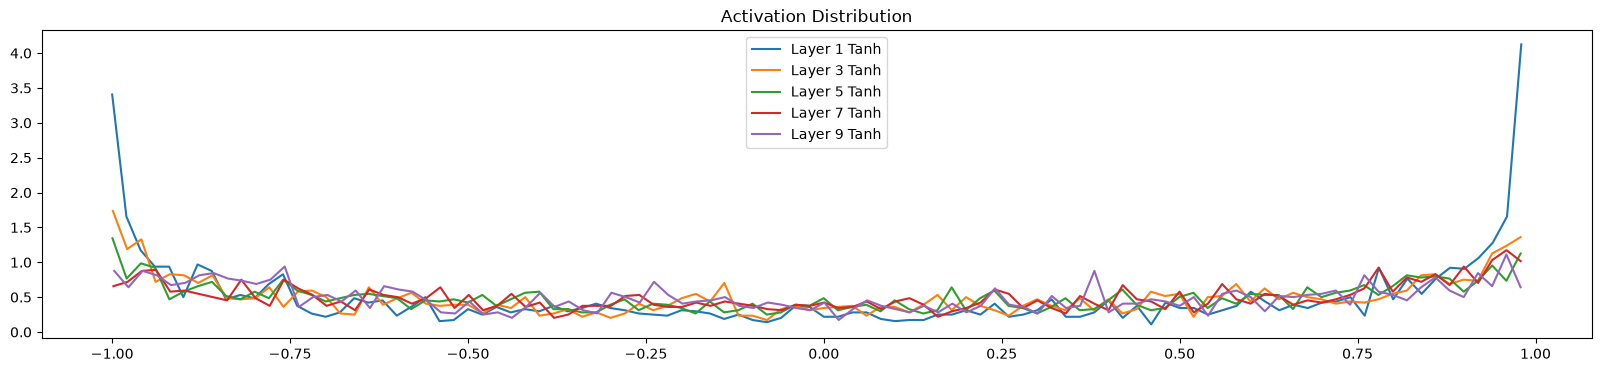

In [27]:
# visualize histograms
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t=layer.out
        print(
            f'Layer: {i} ({layer.__class__.__name__}) '
            f'mean: {t.mean().item():.4f}, '
            f'std: {t.std().item():.4f}, '
            f'saturated: {((t.abs() > 0.97).float().mean() * 100).item():.2f}%'
        )

        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} {layer.__class__.__name__}')
plt.legend(legends)
plt.title("Activation Distribution")

Layer: 1 (Tanh) mean: -0.0000, std: 0.0005 
Layer: 3 (Tanh) mean: -0.0000, std: 0.0004 
Layer: 5 (Tanh) mean: -0.0000, std: 0.0004 
Layer: 7 (Tanh) mean: -0.0000, std: 0.0004 
Layer: 9 (Tanh) mean: -0.0000, std: 0.0003 


Text(0.5, 1.0, 'Activation Distribution')

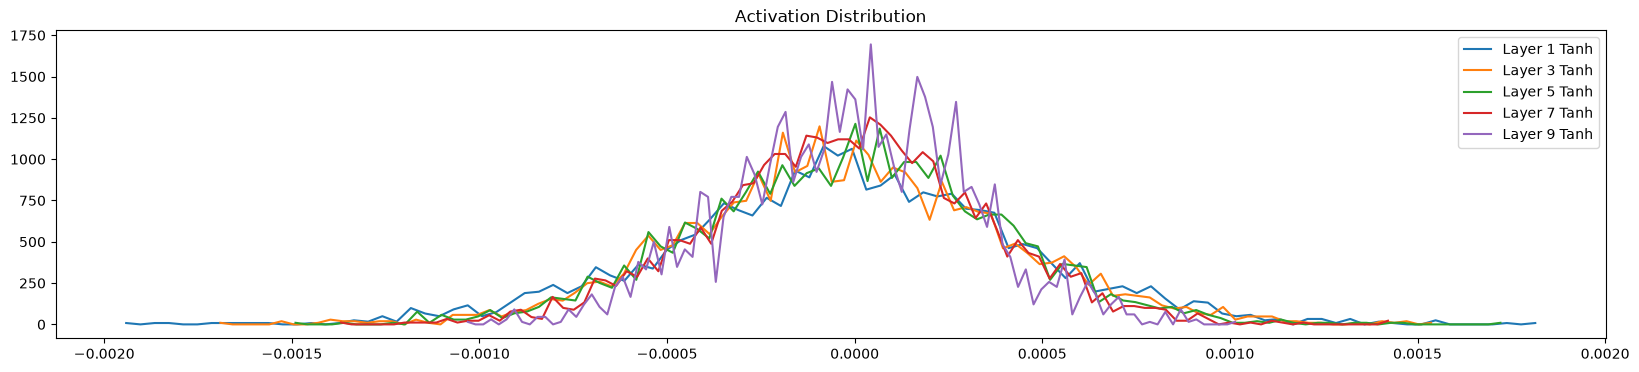

In [28]:
# visualize histograms
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t=layer.out.grad
        print(
            f'Layer: {i} ({layer.__class__.__name__}) '
            f'mean: {t.mean().item():.4f}, '
            f'std: {t.std().item():.4f} '
        )

        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} {layer.__class__.__name__}')
plt.legend(legends)
plt.title("Activation Distribution")

## DOUBT: WHY THE FUCK AM I NOT GETTING PROPER SATURATION AT 5/2 as weight gain? and why is it proper at 0,19? (I just foud out saturation by trial and error that's how I got 0.19) - Check and fix. 

## Doubt Solved: I was forgetting to divide the weights by sqrt of fan in. So the saturation was exploding. 

If there was a symmetry in the actuivations and grads of the layers then it's not good place to be. So it was very hard to do so in the days of batch normalization. 

Why we have tanh layers? If they are not there then all the linear layers collapse to like ONE linear layer. Still the backpropagation is not identical it's still interesting. So basically if 10 linear layers are stacked then it acts as one linear layer. 